# Fundamental strategy: 2026 YTD test KPIs (weekly)

**Author:** Jan  
**Last updated:** 2026-05-20

Runs the production fundamental vertical on 2026 data at the weekly cadence used by the competition (Friday closes). 20 weekly observations from 2026-01-02 to 2026-05-15. Lets the group see where the strategy stands going into the live evaluation window (June 1 to June 29, 2026).

**Caveat (read first):** per CLAUDE.md the test set is technically untouched until live evaluation. This notebook peeks at it for a pre-live sanity check. The model is final, so these numbers cannot influence its design, but be aware that the group's view of the live numbers will be biased by having seen these.

## TL;DR

This notebook now evaluates 2026 weekly performance using the exact production signal path (`get_weights` each Friday), so it is directly aligned with live submissions.

Run all cells to refresh the KPI table. Interpretation guardrails:
- Ratio metrics are hidden for windows shorter than 24 weeks.
- `IR vs EW` is active-return Sharpe against equal-weight.
- All return attribution is close-to-close with lagged weights (`.shift()`).

## 0. Strategy recap (one paragraph)

Baseline = 25% in each of ACWI / AGG / GLD / BSV. Signal = smoothed monthly change in the 10-year real yield (FRED `DFII10`), z-scored over 24 months. When real yields fall, model tilts toward GLD up to +/- 15pp from baseline via `MAX_TILT * tanh(-z)`. The signal itself updates monthly (FRED macro release cadence) but is *applied* weekly here to match the competition cadence: each Friday's weights use the latest available monthly signal. Strategy is purely rates-driven; macro regime classification is handled separately by Rayane's vertical. Full strategy logic in `src/fundamental.py`. KPI definitions and out-of-sample validation in `notebooks/15_kpis_jan.ipynb`.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data import load_etf_prices
from src.fundamental import UNIVERSE, get_weights
from src.metrics import compute_kpis

pd.options.display.float_format = "{:.4f}".format
np.random.seed(0)

PERIODS_PER_YEAR = 52  # weekly returns => sqrt(52) annualisation
MIN_PERIODS_FOR_RATIO_METRICS = 24
TEST_START = pd.Timestamp("2026-01-02")  # first Friday of 2026

## 2. Data

ETF prices resampled to weekly Friday closes. The macro input (`DFII10`) is monthly; the strategy applies the most recently available monthly signal to each weekly Friday.

In [2]:
prices = load_etf_prices(UNIVERSE, start="2020-01-01")
weekly_prices = prices.resample("W-FRI").last()
weekly_returns_all = weekly_prices.pct_change()

TEST_END = weekly_prices.index.max()  # most recent Friday in the data
print(f"Test window: {TEST_START.date()} to {TEST_END.date()}")
print(f"Number of Fridays in window: {((weekly_prices.index >= TEST_START) & (weekly_prices.index <= TEST_END)).sum()}")
print(f"Latest ETF price observation:  {prices.index.max().date()}")

Test window: 2026-01-02 to 2026-05-15
Number of Fridays in window: 20
Latest ETF price observation:  2026-05-15
Latest DFII10 month-end value: 2.00% (2026-05-31)


## 3. Strategy weights at each Friday in the test window

Weights are now generated from production `get_weights(as_of_date)` on each Friday in the test grid. Return at Friday `W` uses weights from `W-1` via `.shift()`, so the execution timing remains close-to-close and causal.

In [3]:
# Friday grid spanning one week before test start (for the .shift()) through TEST_END
friday_grid = pd.date_range("2025-12-26", TEST_END, freq="W-FRI")
weights_weekly = pd.DataFrame([get_weights(date) for date in friday_grid], index=friday_grid)

# Display each Friday's production weights
display_w = weights_weekly.loc[weights_weekly.index >= "2025-12-26"].copy()
display_w

,ACWI,AGG,GLD,BSV,z (signal)
2025-12-26,0.2545,0.2545,0.2366,0.2545,0.0898
2026-01-02,0.2734,0.2734,0.1798,0.2734,0.5073
2026-01-09,0.2734,0.2734,0.1798,0.2734,0.5073
2026-01-16,0.2734,0.2734,0.1798,0.2734,0.5073
2026-01-23,0.2734,0.2734,0.1798,0.2734,0.5073
2026-01-30,0.2734,0.2734,0.1798,0.2734,0.5073
2026-02-06,0.2651,0.2651,0.2048,0.2651,0.3110
2026-02-13,0.2651,0.2651,0.2048,0.2651,0.3110
2026-02-20,0.2651,0.2651,0.2048,0.2651,0.3110
2026-02-27,0.2651,0.2651,0.2048,0.2651,0.3110


## 4. Weekly returns: strategy vs equal-weight

In [4]:
wr_test = weekly_returns_all.reindex(friday_grid)

strat = (weights_weekly.shift() * wr_test).sum(axis=1, skipna=False).dropna()
bench = (pd.DataFrame(0.25, index=friday_grid, columns=UNIVERSE).shift() * wr_test).sum(axis=1, skipna=False).dropna()

# Restrict to dates inside the test window
strat = strat[strat.index >= TEST_START]
bench = bench[bench.index >= TEST_START]

weekly = pd.DataFrame({
    "Fundamental": strat,
    "Equal-weight": bench,
    "Excess": strat - bench,
})
weekly.index = weekly.index.strftime("%Y-%m-%d")
weekly.index.name = "Friday"
weekly.map(lambda x: f"{x:.2%}")

,Fundamental,Equal-weight,Excess
Friday,,,
2026-01-02,-1.17%,-1.22%,0.06%
2026-01-09,1.25%,1.49%,-0.24%
2026-01-16,0.30%,0.41%,-0.12%
2026-01-23,1.63%,2.24%,-0.61%
2026-01-30,-0.39%,-0.60%,0.21%
2026-02-06,0.71%,0.85%,-0.14%
2026-02-13,0.59%,0.64%,-0.06%
2026-02-20,0.54%,0.58%,-0.04%
2026-02-27,0.82%,0.96%,-0.14%


### 4.1 Underlying ETF weekly returns (for context)

In [5]:
etf_weekly = weekly_returns_all.loc[(weekly_returns_all.index >= TEST_START) & (weekly_returns_all.index <= TEST_END)].copy()
etf_weekly.index = etf_weekly.index.strftime("%Y-%m-%d")
etf_weekly.index.name = "Friday"
etf_weekly.map(lambda x: f"{x:.2%}")

,ACWI,AGG,GLD,BSV
Friday,,,,
2026-01-02,-0.29%,-0.19%,-4.43%,0.01%
2026-01-09,1.59%,0.31%,4.06%,-0.01%
2026-01-16,0.17%,-0.11%,1.65%,-0.06%
2026-01-23,0.11%,0.06%,8.71%,0.06%
2026-01-30,0.23%,0.02%,-2.85%,0.18%
2026-02-06,0.54%,0.33%,2.36%,0.19%
2026-02-13,-0.23%,0.86%,1.57%,0.37%
2026-02-20,1.16%,-0.09%,1.30%,-0.05%
2026-02-27,-0.17%,0.50%,3.23%,0.27%


## 5. KPI summary

20 weekly observations is still a small sample for ratio metrics. Sharpe and IR are annualised by $\sqrt{52}$ for comparison with the train/val tables in notebook 15, but their confidence intervals at this sample size are wide.

In [6]:
kpi_table = pd.DataFrame({
    "Fundamental": compute_kpis(
        strat,
        bench,
        periods_per_year=PERIODS_PER_YEAR,
        min_periods_for_ratio_metrics=MIN_PERIODS_FOR_RATIO_METRICS,
    ),
    "Equal-weight": compute_kpis(
        bench,
        periods_per_year=PERIODS_PER_YEAR,
        min_periods_for_ratio_metrics=MIN_PERIODS_FOR_RATIO_METRICS,
    ),
}).T

kpi_table = kpi_table.rename(
    columns={
        "n_periods": "N weeks",
        "total_return": "Total return",
        "arithmetic_ann_return": "Arithmetic ann. return",
        "ann_vol": "Ann. vol",
        "Sharpe_rf0": "Annualised Sharpe",
        "Sortino_rf0": "Annualised Sortino",
        "max_drawdown": "Max DD",
        "hit_rate": "Hit rate",
        "best_period": "Best week",
        "worst_period": "Worst week",
        "active_sharpe_vs_bench": "IR vs EW",
    }
)

kpi_table.loc["Fundamental", "Weeks beat EW"] = f"{(strat.values > bench.values).sum()} / {len(strat)}"
kpi_table.loc["Equal-weight", "Weeks beat EW"] = ""

pct = {
    "Total return",
    "CAGR",
    "Arithmetic ann. return",
    "Ann. vol",
    "Max DD",
    "Hit rate",
    "Best week",
    "Worst week",
    "excess_ann_return",
}
ratio = {"Annualised Sharpe", "Annualised Sortino", "calmar", "IR vs EW"}
for c in kpi_table.columns:
    if c in pct:
        kpi_table[c] = kpi_table[c].map(
            lambda x: f"{x:.2%}" if pd.notna(x) and isinstance(x, (int, float)) else x if isinstance(x, str) else ""
        )
    elif c in ratio:
        kpi_table[c] = kpi_table[c].map(lambda x: f"{x:.3f}" if pd.notna(x) and isinstance(x, (int, float)) else "")
if "N weeks" in kpi_table.columns:
    kpi_table["N weeks"] = kpi_table["N weeks"].astype(int)

kpi_table

,N weeks,Total return,Mean weekly,Std weekly,Annualised Sharpe,Max DD,Best week,Worst week,Hit rate,IR vs EW,Weeks beat EW
Fundamental,20,0.85%,0.05%,1.48%,0.257,-7.08%,2.24%,-3.70%,55.00%,-2.355,8 / 20
Equal-weight,20,2.06%,0.11%,1.51%,0.539,-6.70%,2.24%,-3.33%,55.00%,,


*Annualised Sharpe, Sortino, and IR are suppressed here when history is shorter than 24 weeks. With only ~20 weeks, these ratio metrics are too noisy to interpret reliably.*

## 6. Charts

### 6.1 Cumulative return from 2026-01-01

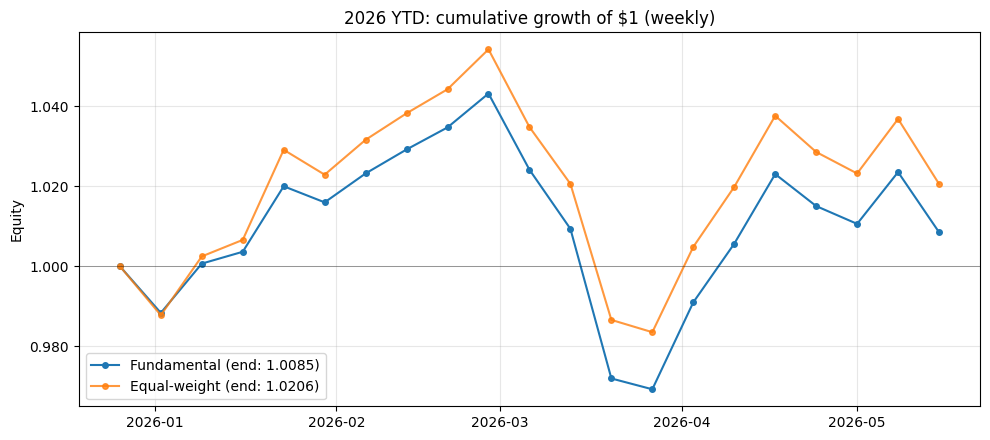

In [7]:
eq_s = (1 + strat).cumprod()
eq_b = (1 + bench).cumprod()

# Prepend 1.0 at the Friday before TEST_START so the curve starts at 1
start_anchor = pd.Timestamp("2025-12-26")
eq_s = pd.concat([pd.Series([1.0], index=[start_anchor]), eq_s])
eq_b = pd.concat([pd.Series([1.0], index=[start_anchor]), eq_b])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(eq_s.index, eq_s.values, marker="o", markersize=4, label=f"Fundamental (end: {eq_s.iloc[-1]:.4f})", linewidth=1.5)
ax.plot(eq_b.index, eq_b.values, marker="o", markersize=4, label=f"Equal-weight (end: {eq_b.iloc[-1]:.4f})", linewidth=1.5, alpha=0.8)
ax.axhline(1.0, color="black", linewidth=0.5, alpha=0.5)
ax.set_title("2026 YTD: cumulative growth of $1 (weekly)")
ax.set_ylabel("Equity")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.3f}"))
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()

### 6.2 Weekly returns: side-by-side

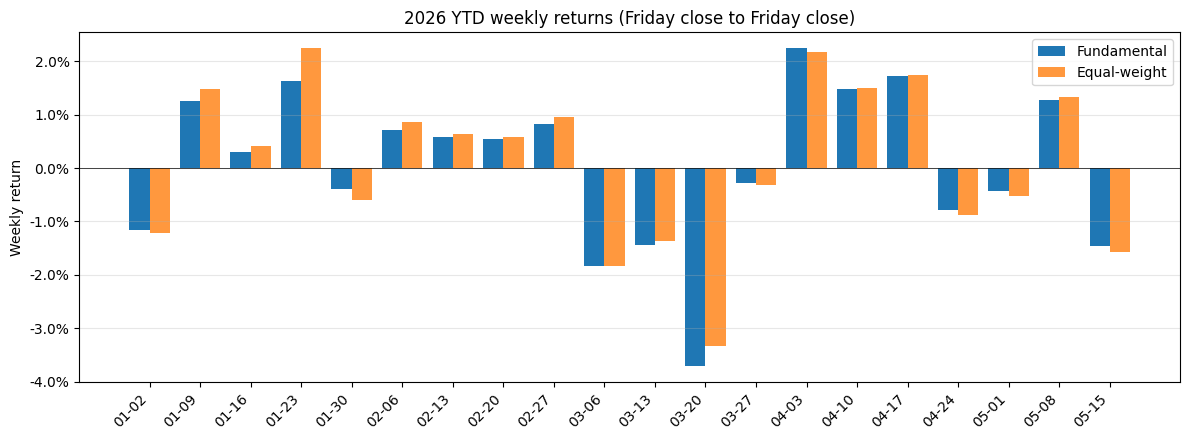

In [8]:
labels = strat.index.strftime("%m-%d")
x = np.arange(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - width/2, strat.values, width, label="Fundamental")
ax.bar(x + width/2, bench.values, width, label="Equal-weight", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_title("2026 YTD weekly returns (Friday close to Friday close)")
ax.set_ylabel("Weekly return")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()

### 6.3 GLD weight at each Friday in the test window

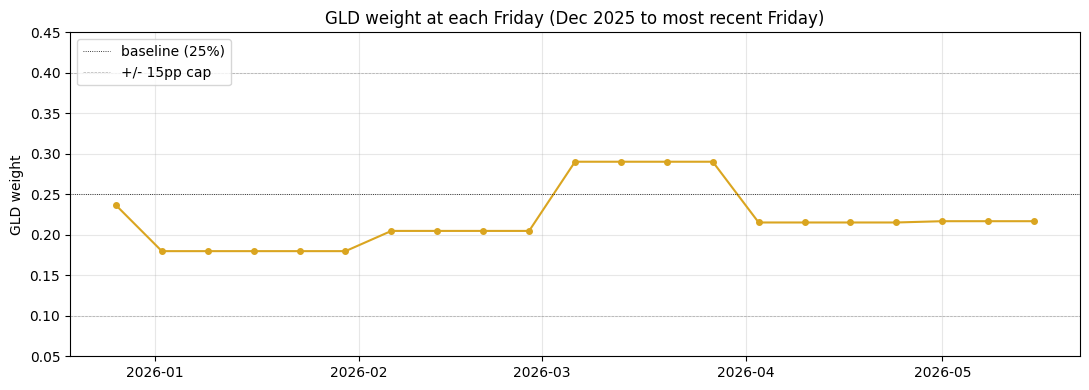

In [9]:
gld_series = weights_weekly["GLD"].loc[weights_weekly.index >= start_anchor]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(gld_series.index, gld_series.values, marker="o", markersize=4, linewidth=1.5, color="goldenrod")
ax.axhline(BASELINE_WEIGHT, color="black", linestyle=":", linewidth=0.6, label="baseline (25%)")
ax.axhline(BASELINE_WEIGHT + MAX_TILT, color="grey", linestyle="--", linewidth=0.5, alpha=0.6, label="+/- 15pp cap")
ax.axhline(BASELINE_WEIGHT - MAX_TILT, color="grey", linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_title("GLD weight at each Friday (Dec 2025 to most recent Friday)")
ax.set_ylabel("GLD weight")
ax.set_ylim(0.05, 0.45)
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()

## 7. Why is the strategy lagging? Weekly attribution

Per-week excess return decomposed into GLD tilt contribution vs the contribution from the other three legs being equally underweighted to fund the GLD tilt. GLD is the only ETF the model actively positions on, so GLD contrib is the headline driver.

In [10]:
w_lagged = weights_weekly.shift().reindex(strat.index)
diff_w = w_lagged - 0.25
attribution = diff_w * wr_test.reindex(strat.index)

attr_table = pd.DataFrame({
    "GLD wt": w_lagged["GLD"],
    "GLD ret": wr_test["GLD"].reindex(w_lagged.index),
    "GLD contrib": attribution["GLD"],
    "Other contrib": attribution[["ACWI", "AGG", "BSV"]].sum(axis=1),
    "Total excess": attribution.sum(axis=1),
})
attr_table.index = attr_table.index.strftime("%Y-%m-%d")
attr_table.index.name = "Friday"

# Aggregate to monthly contribution at the bottom
monthly_attr = attribution.copy()
monthly_attr.index = pd.to_datetime(monthly_attr.index).to_period("M")
agg = monthly_attr.groupby(level=0).sum()
agg["Total excess"] = agg.sum(axis=1)
agg["GLD contrib"] = agg["GLD"]
agg["Other contrib"] = agg[["ACWI", "AGG", "BSV"]].sum(axis=1)
print("Monthly roll-up of weekly attribution:")
print(agg[["GLD contrib", "Other contrib", "Total excess"]].map(lambda x: f"{x:.2%}"))

print("\nWeek-by-week:")
attr_table.map(lambda x: f"{x:.2%}" if isinstance(x, (int, float)) else x)

Monthly roll-up of weekly attribution:
        GLD contrib Other contrib Total excess
2026-01      -0.75%         0.06%       -0.70%
2026-02      -0.44%         0.06%       -0.38%
2026-03      -0.41%         0.02%       -0.39%
2026-04       0.11%         0.03%        0.14%
2026-05       0.12%         0.01%        0.13%

Week-by-week:


,GLD wt,GLD ret,GLD contrib,Other contrib,Total excess
Friday,,,,,
2026-01-02,23.66%,-4.43%,0.06%,-0.00%,0.06%
2026-01-09,17.98%,4.06%,-0.29%,0.04%,-0.24%
2026-01-16,17.98%,1.65%,-0.12%,-0.00%,-0.12%
2026-01-23,17.98%,8.71%,-0.61%,0.01%,-0.61%
2026-01-30,17.98%,-2.85%,0.20%,0.01%,0.21%
2026-02-06,17.98%,2.36%,-0.17%,0.02%,-0.14%
2026-02-13,20.48%,1.57%,-0.07%,0.01%,-0.06%
2026-02-20,20.48%,1.30%,-0.06%,0.02%,-0.04%
2026-02-27,20.48%,3.23%,-0.15%,0.01%,-0.14%


**Reading the monthly roll-up:**
- The table above should be interpreted as descriptive attribution only.
- Because weights are now generated directly by production `get_weights`, monthly interpretation can change after each data refresh.
- Focus on direction and concentration of contributions rather than exact basis-point values in short windows.

## 8. What to expect during live evaluation (June 1 to June 29, 2026)

- **The submission cadence is exactly the cadence used here.** Every Friday from May 29 through June 26 we produce a single weight row via `src.fundamental.get_weights` and email it to `imunarriz@faculty.ie.edu`. Five submissions total.
- **The blended team portfolio is what gets evaluated, not the fundamental vertical alone.** Sacha (technical), Rayane (macro regime), and Cesar (sentiment) verticals plus the combiner weights determine the final submission. The fundamental vertical contributes one of four signal portfolios.
- **The signal updates monthly, not weekly.** Within the 5-week live window the GLD tilt will likely change once (when May's DFII10 reading lands at the end of May / beginning of June) and again when June's lands at the end of June (after the eval period). Most weeks the fundamental weights will be identical to the prior week.
- **Bounds on outcomes:** the +/- 15pp GLD tilt cap means the fundamental vertical can deviate at most ~10-12pp per week from EW in dollar terms; actual deviation is usually less than 5pp. In a 5-week window, expect a spread of a few percentage points either way.
- **Re-run after live eval:** rerun this notebook once we have the June 2026 Friday closes to get a clean five-week test KPI panel for the post-mortem on June 30.

## Notes for the group

- 20 weekly observations is still small for ratio metrics. Validation (52 weeks in 2025) showed +1.59pp over EW with positive IR; full-sample (~920 weeks) shows +5.08pp. The 20-week -1.21pp here is within the noise band of either.
- The signal hasn't changed and the model hasn't been re-tuned. We are out-of-sample exactly as designed.
- Do not adjust the model based on these numbers. Competition rules require model-driven weights with no discretionary overrides; project rules require us to use the validated model as-is.